<a href="https://colab.research.google.com/github/dithya-332/ml-lab/blob/main/diabetes4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score

In [5]:
#load diabetes Dataset
diabetes=load_diabetes()
x=dia                                                                                                                                                                                                                                                         betes.data
y=diabetes.target

In [8]:
#train-test split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42)


In [10]:
#feature scaling
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
print("training samples:",x_train.shape[0])
print("testing samples:",x_test.shape[0])

training samples: 353
testing samples: 89


In [11]:
linear_model=LinearRegression()
linear_model.fit(x_train_scaled,y_train)
y_pred_linear=linear_model.predict(x_test_scaled)
print("Linear Regression")
print("MSE=",mean_squared_error(y_test,y_pred_linear))
print("R2 =",r2_score(y_test,y_pred_linear))

Linear Regression
MSE= 2900.1936284934823
R2 = 0.45260276297191926


In [12]:
ridge=Ridge()
param_grid={'alpha':[0.01,0.1,1,10,100]}
ridge_cv=GridSearchCV(ridge,param_grid,cv=5)
ridge_cv.fit(x_train_scaled,y_train)
best_ridge=ridge_cv.best_estimator_
y_pred_ridge=best_ridge.predict(x_test_scaled)
print("Best Alpha for Ridge:",ridge_cv.best_params_['alpha'])
print("MSE=",mean_squared_error(y_test,y_pred_ridge))
print("R2 =",r2_score(y_test,y_pred_ridge))

Best Alpha for Ridge: 10
MSE= 2875.7787184218428
R2 = 0.4572109567780849


In [16]:
lasso=Lasso(max_iter=10000)
lasso_cv=GridSearchCV(lasso,param_grid,cv=5)
lasso_cv.fit(x_train_scaled,y_train)
best_lasso=lasso_cv.best_estimator_
y_pred_lasso=best_lasso.predict(x_test_scaled)
print("Best Alpha for Lasso:",lasso_cv.best_params_['alpha'])
print("MSE=",mean_squared_error(y_test,y_pred_lasso))
print("R2 =",r2_score(y_test,y_pred_lasso))

Best Alpha for Lasso: 1
MSE= 2824.568094049959
R2 = 0.46687670944102466


In [19]:
results=pd.DataFrame({
    'Model':['Linear Regression','Ridge regression','Lasso'],
    'MSE':[mean_squared_error(y_test,y_pred_linear),
           mean_squared_error(y_test,y_pred_ridge),
           mean_squared_error(y_test,y_pred_lasso)],
    'R2 score':[r2_score(y_test,y_pred_linear),
           r2_score(y_test,y_pred_ridge),
           r2_score(y_test,y_pred_lasso)]
})
print(results)

               Model          MSE  R2 score
0  Linear Regression  2900.193628  0.452603
1   Ridge regression  2875.778718  0.457211
2              Lasso  2824.568094  0.466877


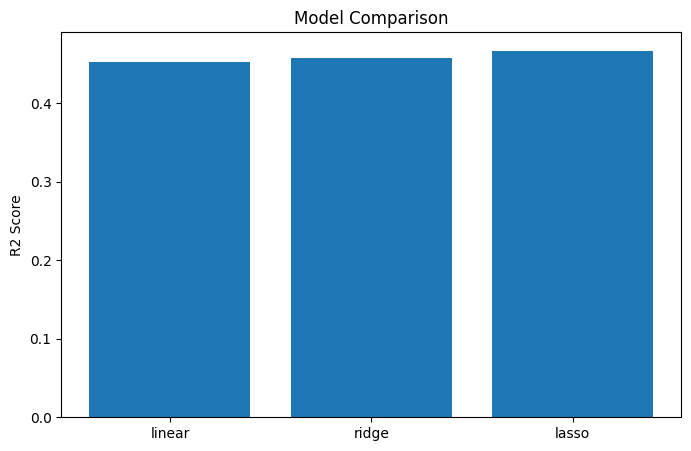

In [21]:
plt.figure(figsize=(8,5))
models=['linear','ridge','lasso']
r2_scores=[r2_score(y_test,y_pred_linear),
           r2_score(y_test,y_pred_ridge),
           r2_score(y_test,y_pred_lasso)
           ]
plt.bar(models,r2_scores)
plt.ylabel('R2 Score')
plt.title('Model Comparison')
plt.show()